Dielectric Validation

In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import xarray as xr
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import glob

sys.path.append(str(Path("../src").resolve()))
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity
from radar_lwc.preprocessing.clean import drop_duplicate_times
from radar_lwc.preprocessing.align import align_to_reference_time
from radar_lwc.retrieval.kappa_liquid import kappa_liquid
from radar_lwc.retrieval.dielectric import epsilon_water_liebe1989
from radar_lwc.retrieval.zhu import retrieve_lwc_zhu

In [2]:
in_path = Path("../data/processed/aligned.nc")
ds = xr.open_dataset(in_path)
print(ds)

<xarray.Dataset> Size: 43MB
Dimensions:  (Time: 10441, range: 339)
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt     (range) float32 1kB ...
Data variables:
    Ze_W     (Time, range) float32 14MB ...
    Ze_Ka    (Time, range) float32 14MB ...
    T_cloud  (Time, range) float32 14MB ...
Attributes:
    description:  Aligned W/Ka reflectivities + T field for LWC retrieval
    date:         20230928
    site:         Cabauw
    Ze_units:     dBZ
    created_by:   02_align.ipynb


DWR HERE FIRST

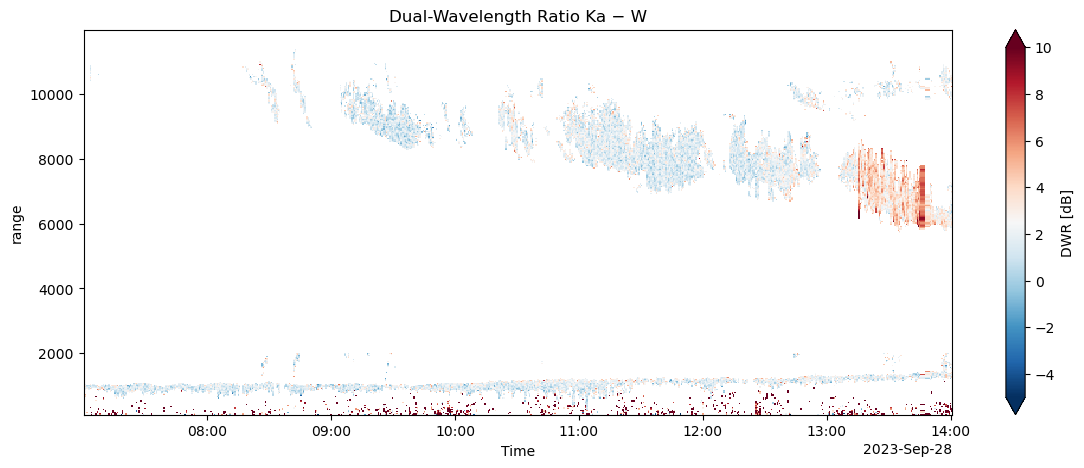

In [3]:
dwr = ds["Ze_Ka"]- ds["Ze_W"]      # in dB
dwr.name = "DWR"
dwr.attrs["units"] = "dB"
fig, ax = plt.subplots(figsize=(14, 5))
dwr.plot(x="Time", y="range", cmap="RdBu_r", vmin=-5, vmax=10, ax=ax, cbar_kwargs={"label": "DWR [dB]"})
ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

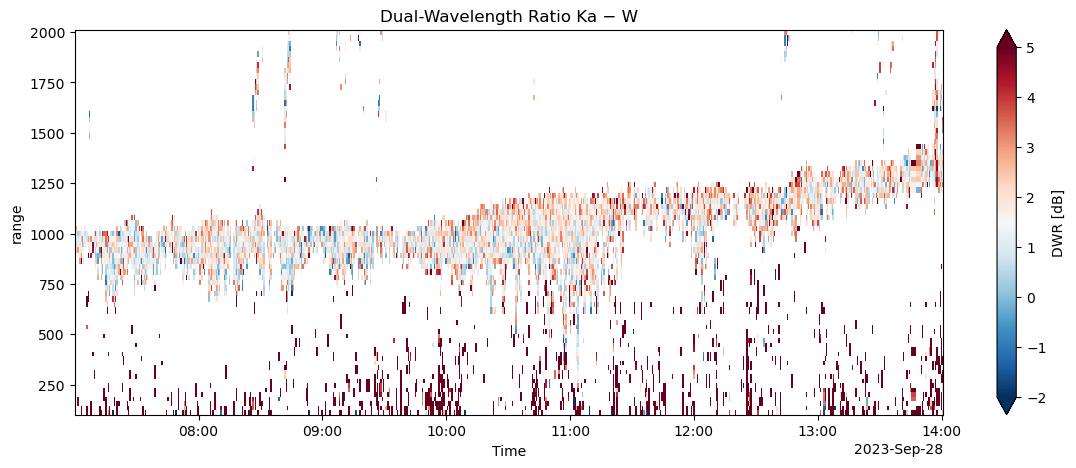

In [4]:
dwr_2km = dwr.sel(range=slice(0, 2000))

fig, ax = plt.subplots(figsize=(14, 5))

dwr_2km.plot(
    x="Time",
    y="range",
    cmap="RdBu_r",
    vmin=-2,
    vmax=5,
    ax=ax,
    cbar_kwargs={"label": "DWR [dB]"}
)

ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

In [11]:
# 1. Confirm DWR is in dB
print("DWR stats (cloud only):")
cloud_dwr = dwr.where(dwr > 0).where(dwr < 20)  # rough cloud filter
print(f"  median: {float(cloud_dwr.median()):.2f}")
print(f"  90th pct: {float(cloud_dwr.quantile(0.9)):.2f}")
print(f"  range: {float(cloud_dwr.min()):.2f} to {float(cloud_dwr.max()):.2f}")

# 2. Confirm range axis
print(f"\nRange axis: first={float(dwr['range'][0]):.1f} m, last={float(dwr['range'][-1]):.1f} m")
print(f"Δh = {float(dwr['range'][1] - dwr['range'][0]):.1f} m")

# 3. Check kappa
print(f"\nkappa_W: {float(kappa_w.mean()):.3f} dB/km/(g/m³)")
print(f"kappa_Ka: {float(kappa_ka.mean()):.3f} dB/km/(g/m³)")
print(f"Δκ: {float((kappa_w - kappa_ka).mean()):.3f}")


DWR stats (cloud only):
  median: 2.05
  90th pct: 4.56
  range: 0.00 to 20.00

Range axis: first=111.8 m, last=11974.8 m
Δh = 22.4 m

kappa_W: 4.290 dB/km/(g/m³)
kappa_Ka: 0.800 dB/km/(g/m³)
Δκ: 3.490


In [12]:
print(float(dwr.min()))
print(float(dwr.max()))

-15.36152458190918
52.93231964111328


KAPPA AND ALPHA CALCULATION AND PLACEHOLDERS FOR NOW

In [10]:
eps35 = epsilon_water_liebe1989(35.0, 10.0)
eps94 = epsilon_water_liebe1989(94.0, 10.0)

print(eps35)
print(eps94)

(14.529118996612565-25.186642123507625j)
(6.8077640928799354-10.716147683385891j)


In [9]:
print(kappa_liquid(35.0, 10.0))
print(kappa_liquid(94.0, 10.0))

0.7956729460013171
4.288582543382424


In [8]:
for T in [-20, -10, 0, 10, 20]:
    print(
        T,
        kappa_liquid(35, T),
        kappa_liquid(94, T)
    )

-20 1.6600481771453366 4.425787426921649
-10 1.354247474565436 4.819425687164461
0 1.033342978498033 4.734616820726847
10 0.7956729460013171 4.288582543382424
20 0.633487396048754 3.7586066561320375


In [7]:
alpha_w = xr.DataArray(
    np.full_like(dwr.values, 0.65),
    dims=dwr.dims,
    coords=dwr.coords,
    name="alpha_W",
)

alpha_ka = xr.DataArray(
    np.full_like(dwr.values, 0.14),
    dims=dwr.dims,
    coords=dwr.coords,
    name="alpha_Ka",
)

In [6]:
kappa_w = xr.DataArray(
    np.full_like(dwr.values, 4.29),
    dims=dwr.dims,
    coords=dwr.coords,
    name="kappa_W",
)

kappa_ka = xr.DataArray(
    np.full_like(dwr.values, 0.80),
    dims=dwr.dims,
    coords=dwr.coords,
    name="kappa_Ka",
)

CLOUD MASK PLACEHOLDER AND FIRST TRY TO IMPLEMENT EARLY VERSION

In [ ]:
# cloud_mask = xr.DataArray(
#     np.ones_like(dwr.values, dtype=bool),
#     dims=dwr.dims,
#     coords=dwr.coords,
#     name="cloud_mask",
# )

In [14]:
# %% Real cloud mask (replace the all-True placeholder)
# Cloud = both radars see a return above noise floor.
# -40 dBZ is a conservative Ka-band cloud detection threshold.
cloud_mask = (
    ds["Ze_Ka"].notnull()
    & ds["Ze_W"].notnull()
    & (ds["Ze_Ka"] > -40)
    & (ds["Ze_W"] > -40)
)
cloud_mask.name = "cloud_mask"
print(f"Cloud fraction (full column): {float(cloud_mask.mean()):.2%}")

# 2 km version to match your existing workflow
cloud_mask_2km = cloud_mask.sel(range=slice(0, 2000))
print(f"Cloud fraction (0–2 km):     {float(cloud_mask_2km.mean()):.2%}")


Cloud fraction (full column): 9.04%
Cloud fraction (0–2 km):     13.55%


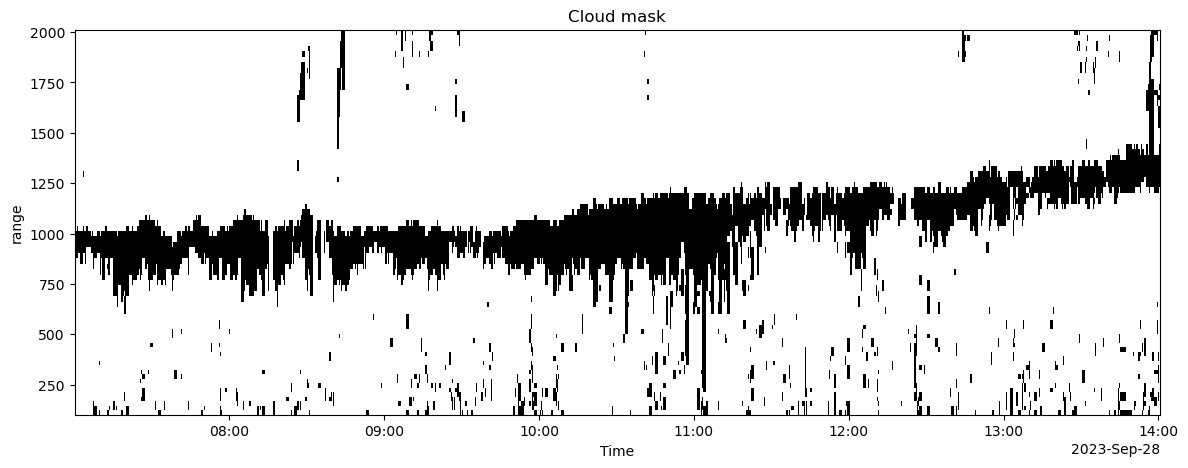

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

cloud_mask.sel(range=slice(0, 2000)).plot(
    x="Time",
    y="range",
    cmap="Greys",
    add_colorbar=False,
    ax=ax,
)

ax.set_title("Cloud mask")
plt.show()

In [16]:
dwr_2km = dwr.sel(range=slice(0, 2000))
cloud_mask_2km = cloud_mask.sel(range=slice(0, 2000))

alpha_w_2km = alpha_w.sel(range=slice(0, 2000))
alpha_ka_2km = alpha_ka.sel(range=slice(0, 2000))

kappa_w_2km = kappa_w.sel(range=slice(0, 2000))
kappa_ka_2km = kappa_ka.sel(range=slice(0, 2000))

LWC RETRIEVAL AND PLOTTING

In [17]:
lwc, derivative = retrieve_lwc_zhu(
    dwr=dwr_2km,
    kappa_w=kappa_w_2km,
    kappa_ka=kappa_ka_2km,
    alpha_w=alpha_w_2km,
    alpha_ka=alpha_ka_2km,
    cloud_mask=cloud_mask_2km,
    N_default=9,
    min_cloud_gates=3,
)

<xarray.DataArray 'LWC' (Time: 10441, range: 74)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(10441, 74))
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 296B 111.8 134.2 156.5 ... 1.971e+03 1.998e+03
    TAlt     (range) float32 296B 111.8 134.2 156.5 ... 1.971e+03 1.998e+03
Attributes:
    units:                      g m-3
    long_name:                  Liquid Water Content (Zhu et al. 2019 retrieval)
    method:                     Sliding-window quadratic DWR gradient
    window_size_default_gates:  9
    min_cloud_gates:            3


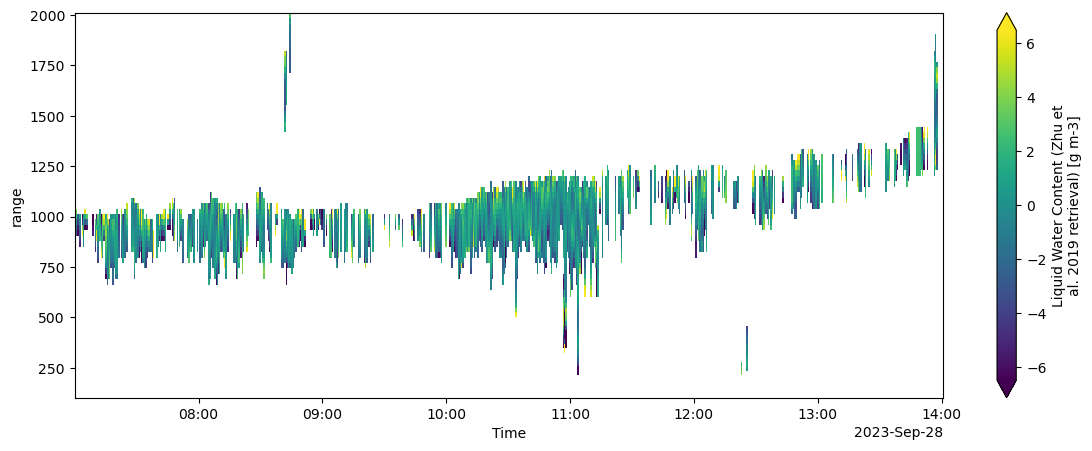

In [18]:
print(lwc)

lwc.plot(
    x="Time",
    y="range",
    figsize=(14, 5),
    cmap="viridis",
    robust=True,
)

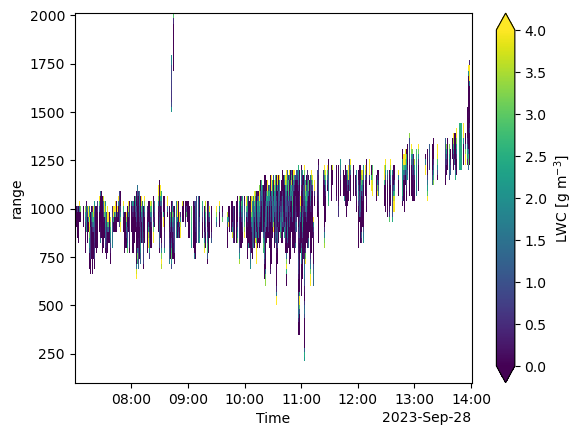

In [19]:
lwc.plot(
    x="Time",
    y="range",
    cmap="viridis",
    vmin=0,
    vmax=4,
    cbar_kwargs={"label": "LWC [g m$^{-3}$]"}
)

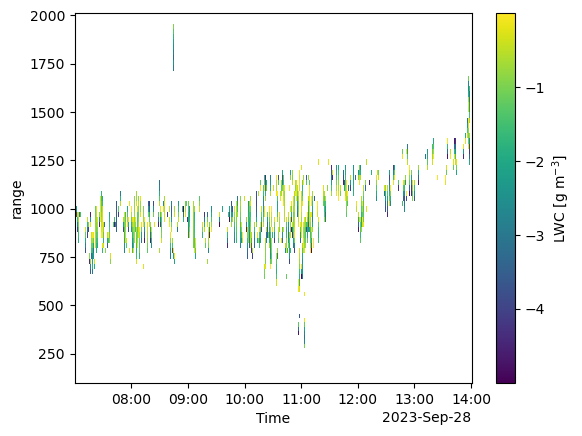

In [20]:
lwc_filtered = lwc.where((lwc >= -5) & (lwc <= 0))
lwc_filtered.plot(
    x="Time",
    y="range",
    cmap="viridis",
    cbar_kwargs={"label": "LWC [g m$^{-3}$]"}
)

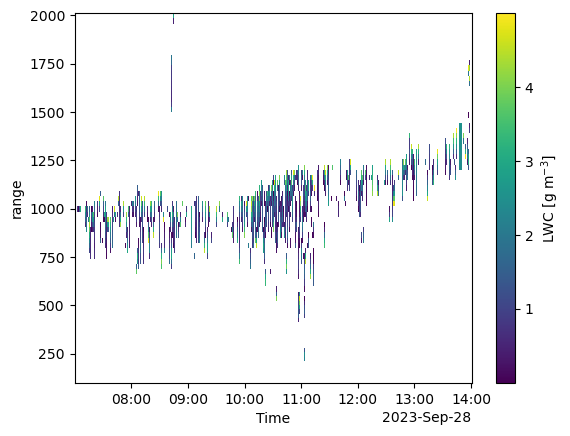

In [21]:
lwc_filtered = lwc.where((lwc >= 0) & (lwc <= 5))
lwc_filtered.plot(
    x="Time",
    y="range",
    cmap="viridis",
    cbar_kwargs={"label": "LWC [g m$^{-3}$]"}
)

In [22]:
# Height spacing between radar gates (m)
dz = float(ds["range"].diff("range").mean())
print(f"Gate spacing = {dz:.1f} m")
# Integrate LWC over height
lwp = (lwc * dz).sum(dim="range") /1000

lwp.name = "LWP"
lwp.attrs["units"] = "kg m^-2"

Gate spacing = 35.1 m


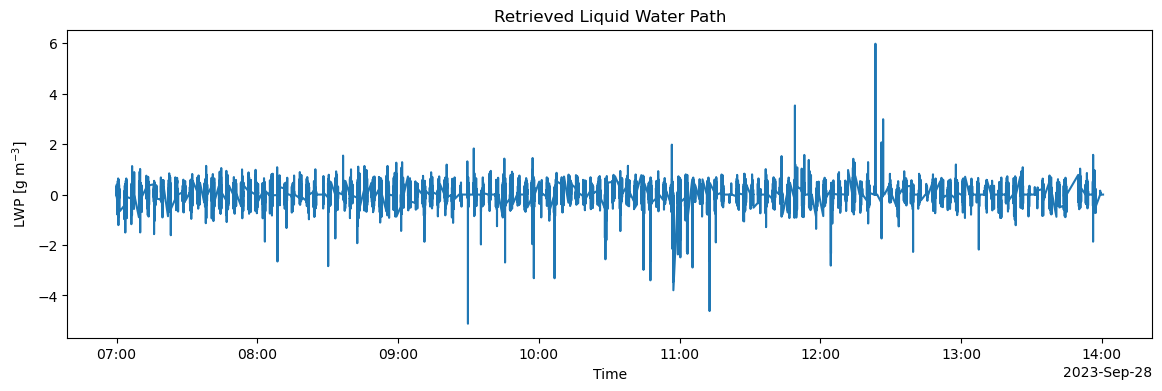

In [23]:
fig, ax = plt.subplots(figsize=(14, 4))

lwp.plot(ax=ax)

ax.set_title("Retrieved Liquid Water Path")
ax.set_ylabel("LWP [g m$^{-3}$]")
ax.set_xlabel("Time")

plt.show()

dDWR_dH

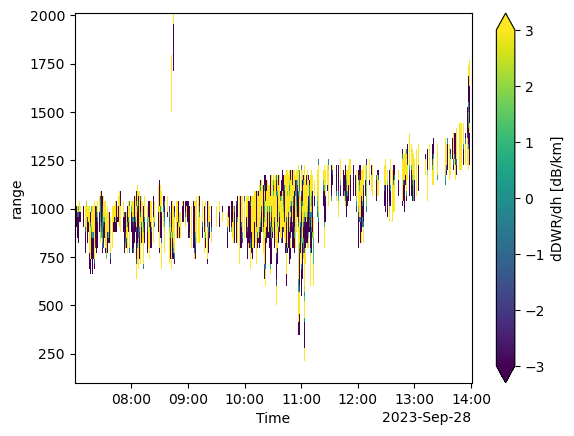

In [28]:
derivative.plot(
    x="Time",
    y="range",
    cmap="viridis",
    vmin=-3,
    vmax=3,
    cbar_kwargs={"label": "dDWR/dh [dB/km]"}
)

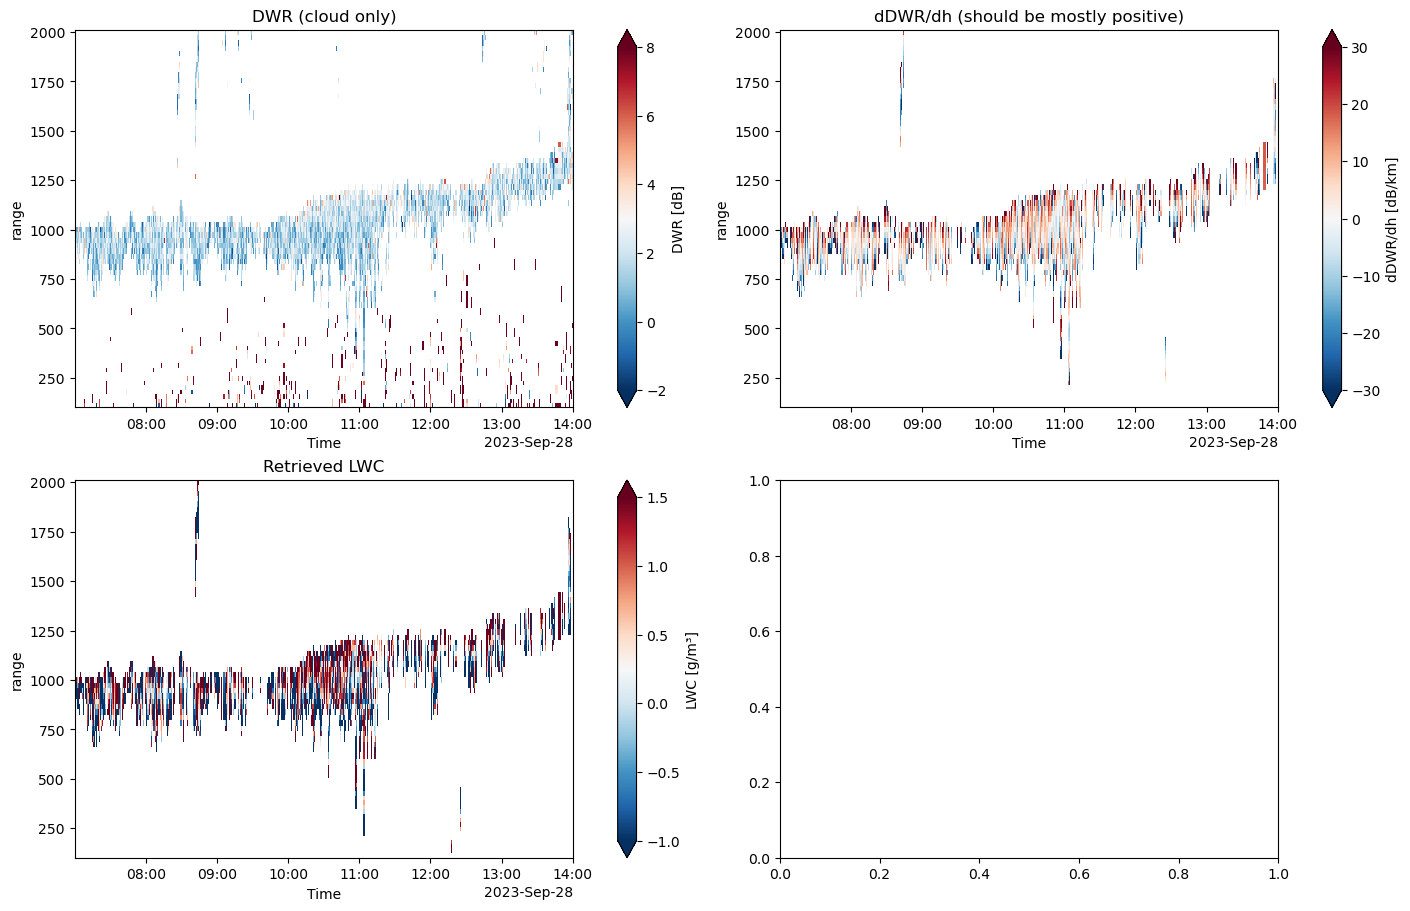

In [30]:
# %% Four diagnostic panels
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

# Panel 1: DWR in cloud
dwr_2km.where(cloud_mask_2km).plot(
    x="Time", y="range", ax=axes[0, 0],
    vmin=-2, vmax=8, cmap="RdBu_r",
    cbar_kwargs={"label": "DWR [dB]"})
axes[0, 0].set_title("DWR (cloud only)")

# Panel 2: dDWR/dh in cloud
derivative.where(cloud_mask_2km).plot(
    x="Time", y="range", ax=axes[0, 1],
    vmin=-30, vmax=30, cmap="RdBu_r",
    cbar_kwargs={"label": "dDWR/dh [dB/km]"})
axes[0, 1].set_title("dDWR/dh (should be mostly positive)")

# Panel 3: LWC in cloud (your existing retrieval)
lwc.where(cloud_mask_2km).plot(
    x="Time", y="range", ax=axes[1, 0],
    vmin=-1, vmax=1.5, cmap="RdBu_r",
    cbar_kwargs={"label": "LWC [g/m³]"})
axes[1, 0].set_title("Retrieved LWC")


plt.show()


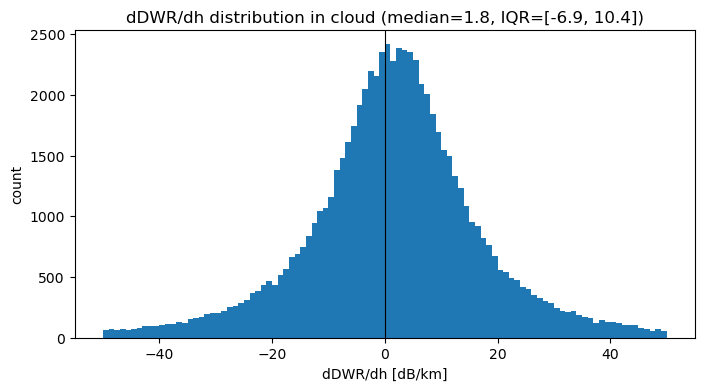

Fraction of gates with dDWR/dh < 0:   44.17%
Fraction with |dDWR/dh| > 30 dB/km:   9.81%


In [31]:
# %% Histogram of dDWR/dh in cloud
fig, ax = plt.subplots(figsize=(8, 4))
vals = derivative.where(cloud_mask_2km).values.ravel()
vals = vals[np.isfinite(vals)]
ax.hist(vals, bins=100, range=(-50, 50))
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("dDWR/dh [dB/km]")
ax.set_ylabel("count")
ax.set_title(f"dDWR/dh distribution in cloud "
             f"(median={np.median(vals):.1f}, "
             f"IQR=[{np.percentile(vals,25):.1f}, {np.percentile(vals,75):.1f}])")
plt.show()

print(f"Fraction of gates with dDWR/dh < 0:   {(vals < 0).mean():.2%}")
print(f"Fraction with |dDWR/dh| > 30 dB/km:   {(np.abs(vals) > 30).mean():.2%}")


MASKING